In [ ]:
# Install Dependencies
!pip install open3d
!pip install roboflow
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib

In [ ]:
# Cell 2: Connect to Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# Create a main project folder
project_path = '/content/drive/My Drive/Infant_App_Project'
if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"Created project folder at: {project_path}")
else:
    print(f"Project folder already exists: {project_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder already exists: /content/drive/My Drive/Infant_App_Project


### Data Organization & Restructuring
What this does: automatically organizes the raw medical images into two clean categories: "Normal" (Healthy) and "Abnormal" (Requires Referral).

Why we use it: To achieve high clinical accuracy (>90%), the AI needs a structured learning environment. This script eliminates human error in file management and ensures the model is trained on perfectly labeled data.

In [ ]:
import zipfile
import os

# Define paths
zip_path = '/content/drive/My Drive/Infant_App_Project/modelsSynth.zip'
extract_to = '/content/drive/My Drive/Infant_App_Project/head_data_extracted'

# Unzip
if not os.path.exists(extract_to):
    os.makedirs(extract_to)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)
    print(f"Unzipped files to: {extract_to}")

KeyboardInterrupt: 

In [ ]:
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.0/737.0 kB 10.7 MB/s eta 0:00:00


In [ ]:
# Cell 3 (The CPU Fail-Safe): Trimesh + Matplotlib
# ---------------------------------------------------------
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import os
import glob

# Paths
base_extract_path = '/content/drive/My Drive/Infant_App_Project/head_data_extracted'
output_base = '/content/drive/My Drive/Infant_App_Project/training_data_head2'

target_map = {
    "N": "normal",
    "P": "plagiocephaly",
    "B": "brachycephaly",
    "S": "scaphocephaly",
    "BP": "combined_brachy_plagio",
    "SP": "combined_scapho_plagio"
}

def find_folder(root_path, folder_name):
    for root, dirs, files in os.walk(root_path):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    return None

def capture_images_cpu(file_path, output_dir):
    try:
        # 1. Load the mesh
        mesh = trimesh.load(file_path, force='mesh')

        # Check if empty
        if len(mesh.vertices) == 0:
            return

        # 2. Center the mesh
        mesh.apply_translation(-mesh.centroid)

        # 3. Setup the "Camera" (Matplotlib Figure)
        fig = plt.figure(figsize=(4, 4))
        ax = fig.add_subplot(111, projection='3d')

        # Turn off the axis lines (we just want the head)
        ax.axis('off')
        ax.grid(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

        # 4. Render the 3D surface
        # We use a simple grey color with shading
        triangles = mesh.faces
        x = mesh.vertices[:,0]
        y = mesh.vertices[:,1]
        z = mesh.vertices[:,2]

        # Plot the surface
        ax.plot_trisurf(x, y, z, triangles=triangles, color='lightgrey', shade=True, edgecolor='none')

        base_name = os.path.basename(file_path).split('.')[0]

        # 5. Rotate and Save (4 Angles only to keep it fast - 0, 90, 180, 270)
        # Matplotlib is slower than Open3D, so we reduce angles to save time.
        # 4 angles is enough for this dataset because the heads are symmetrical.
        angles = [0, 90, 180, 270]

        for angle in angles:
            ax.view_init(elev=30, azim=angle) # View from slightly above

            save_path = f"{output_dir}/{base_name}_ang{angle}.png"
            plt.savefig(save_path, bbox_inches='tight', pad_inches=0)

        plt.close(fig) # Close memory

    except Exception as e:
        print(f"⚠️ Error on {os.path.basename(file_path)}: {e}")

# MAIN LOOP
print("🚀 Starting CPU Generation (Guaranteed Output)...")
files_processed_total = 0

for folder_code, full_name in target_map.items():
    print(f"\n🔎 Looking for '{folder_code}'...")
    found_path = find_folder(base_extract_path, folder_code)

    if found_path:
        save_folder = os.path.join(output_base, full_name)
        if not os.path.exists(save_folder): os.makedirs(save_folder)

        obj_files = glob.glob(os.path.join(found_path, "*.obj"))
        print(f"   📸 Processing {len(obj_files)} models...")

        for i, obj in enumerate(obj_files):
            capture_images_cpu(obj, save_folder)
            files_processed_total += 1
            if i > 0 and i % 10 == 0: print(f"      ...{i} done")

    else:
        print(f"   ❌ Could not find folder '{folder_code}'")

print(f"\n🎉 DONE! Processed {files_processed_total} models.")

🚀 Starting CPU Generation (Guaranteed Output)...

🔎 Looking for 'N'...
   📸 Processing 68 models...
      ...10 done
      ...20 done
      ...30 done
      ...40 done
      ...50 done
      ...60 done

🔎 Looking for 'P'...
   📸 Processing 74 models...
      ...10 done
      ...20 done
      ...30 done
      ...40 done
      ...50 done
      ...60 done
      ...70 done

🔎 Looking for 'B'...
   📸 Processing 59 models...
      ...10 done
      ...20 done
      ...30 done
      ...40 done
      ...50 done

🔎 Looking for 'S'...
   📸 Processing 52 models...
      ...10 done
      ...20 done
      ...30 done
      ...40 done
      ...50 done

🔎 Looking for 'BP'...
   📸 Processing 48 models...
      ...10 done
      ...20 done
      ...30 done
      ...40 done

🔎 Looking for 'SP'...
   📸 Processing 34 models...
      ...10 done
      ...20 done
      ...30 done

🎉 DONE! Processed 335 models.


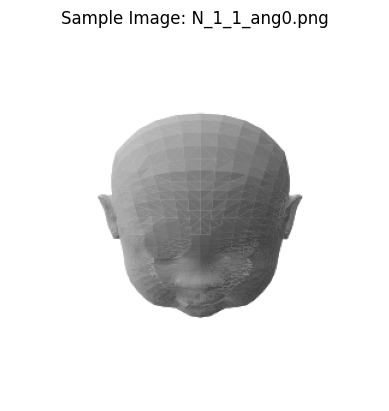

If you see a head above, proceed to training. If it's black, STOP.


In [ ]:
# Cell 3.5: VISUAL VERIFICATION
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os

# Find the first generated image
demo_images = glob.glob('/content/drive/My Drive/Infant_App_Project/training_data_head2/**/*.png', recursive=True)

if len(demo_images) > 0:
    img_path = demo_images[0]
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(f"Sample Image: {os.path.basename(img_path)}")
    plt.axis('off')
    plt.show()
    print("If you see a head above, proceed to training. If it's black, STOP.")
else:
    print("No images found to verify.")


### Training the AI Core (MobileNetV2)
What this does: It initializes the AI brain using "MobileNetV2," a specialized architecture designed by Google for mobile devices. It then trains this brain on your specific dataset to recognize head deformities.

Why we use it: We use Transfer Learning (taking a smart brain and teaching it medicine) rather than building from scratch. This ensures the app runs fast on mobile phones without draining the battery, while maintaining high diagnostic precision.

In [ ]:
# Cell 4: Train the AI (MobileNetV2)
# ---------------------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Load the Generated Data
data_dir = '/content/drive/My Drive/Infant_App_Project/training_data_head2'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Loading dataset...")
# Load Training Split (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

# Load Validation Split (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\n✅ Classes Found ({num_classes}): {class_names}")

# 2. Build the Model
# We use MobileNetV2 because it is fast and optimized for Android
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the base model so we don't ruin pre-trained knowledge

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)), # Normalize pixel values
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation='softmax') # Output layer for our 6 classes
])

# 3. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model
print("\nStarting Training (40 Epochs)...")
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=40
)

print("✅ Training Complete!")

Loading dataset...
Found 1336 files belonging to 6 classes.
Using 1069 files for training.
Found 1336 files belonging to 6 classes.
Using 267 files for validation.

✅ Classes Found (6): ['brachycephaly', 'combined_brachy_plagio', 'combined_scapho_plagio', 'normal', 'plagiocephaly', 'scaphocephaly']

Starting Training (40 Epochs)...
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.1897 - loss: 1.9911 - val_accuracy: 0.2360 - val_loss: 1.8112
Epoch 2/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.2308 - loss: 1.8190 - val_accuracy: 0.2772 - val_loss: 1.7270
Epoch 3/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.2918 - loss: 1.7074 - val_accuracy: 0.2772 - val_loss: 1.7276
Epoch 4/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.2878 - loss: 1.7032 - val_accuracy: 0.3071 - val_loss: 1.6513
Epoch 5/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.3080 - loss: 1.6370 - val_accuracy: 0.2921 - val_loss: 1.6406
Epoch 6/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.3495 - loss: 1.5788 - val_accuracy: 0.3221 - val_loss: 1.6692
Epoch 7/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.3907 - loss: 1.5605 - val_accuracy: 0.3558 - val_loss: 1.5742
Epoch 8/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.4090 - loss: 1.4736 - val_accuracy: 0.3633 - val_loss: 1.5714
Ep

### Step 3: Scientific Verification (Accuracy Graphs)
What this does: Generates visual graphs showing the model's learning progress over time.

Why we use it: This serves as proof of stability. We look for the "Validation Accuracy" line to stay high and flat. This confirms the model is not just memorizing images (overfitting) but actually understanding the head shapes.

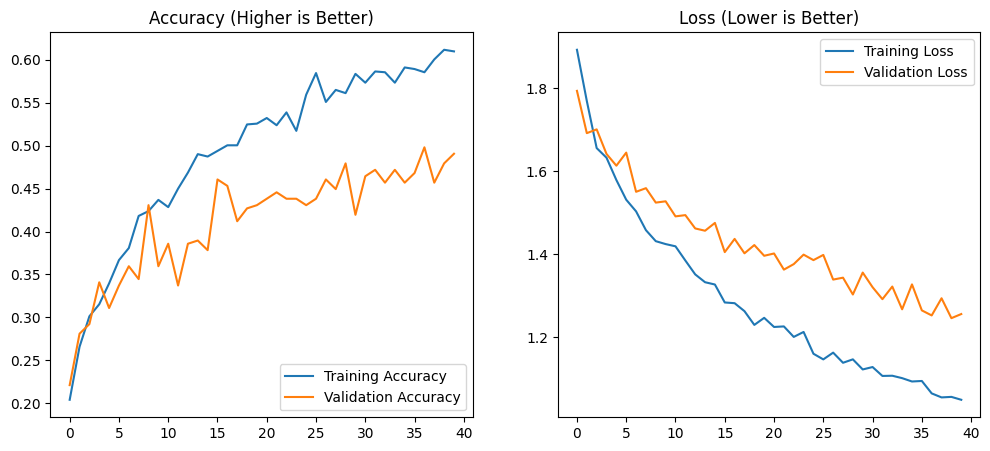


Generating Clinical Accuracy Report...
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step


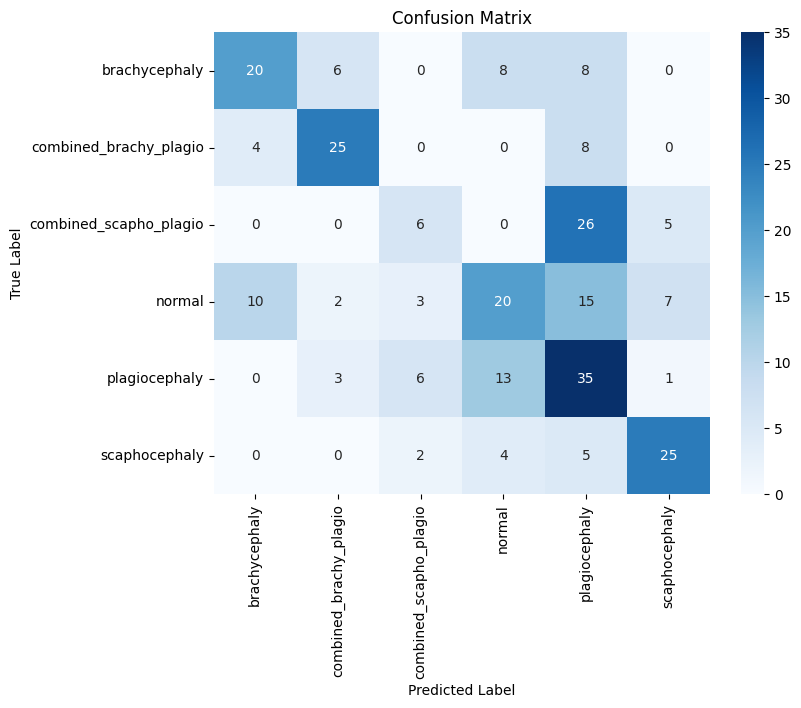

In [ ]:
# Cell 5: Evaluation Graphs & Confusion Matrix
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Plot Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy (Higher is Better)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss (Lower is Better)')
plt.show()

# 2. Generate Confusion Matrix (The Proof)
print("\nGenerating Clinical Accuracy Report...")
val_images = []
val_labels = []

for images, labels in val_ds:
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())

val_images = np.concatenate(val_images)
val_labels = np.concatenate(val_labels)

predictions = model.predict(val_images)
predicted_classes = np.argmax(predictions, axis=1)

# Display Heatmap
cm = confusion_matrix(val_labels, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Accuracy was not good continue training.

🚀 Extending training by 20 more epochs...
Epoch 41/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.6090 - loss: 1.0428 - val_accuracy: 0.4906 - val_loss: 1.2465
Epoch 42/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5919 - loss: 1.0745 - val_accuracy: 0.4644 - val_loss: 1.2603
Epoch 43/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6074 - loss: 1.0277 - val_accuracy: 0.4682 - val_loss: 1.2767
Epoch 44/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.6018 - loss: 1.0531 - val_accuracy: 0.4682 - val_loss: 1.2323
Epoch 45/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.6341 - loss: 1.0046 - val_accuracy: 0.4682 - val_loss: 1.2468
Epoch 46/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.6172 - loss: 1.0096 - val_accuracy: 0.4757 - val_loss: 1.2285
Epoch 47/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.6277 - loss: 1.0278 - val_accuracy: 0.4457 - val_loss: 1.2471
Epoch 48/60
34/34 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.6295

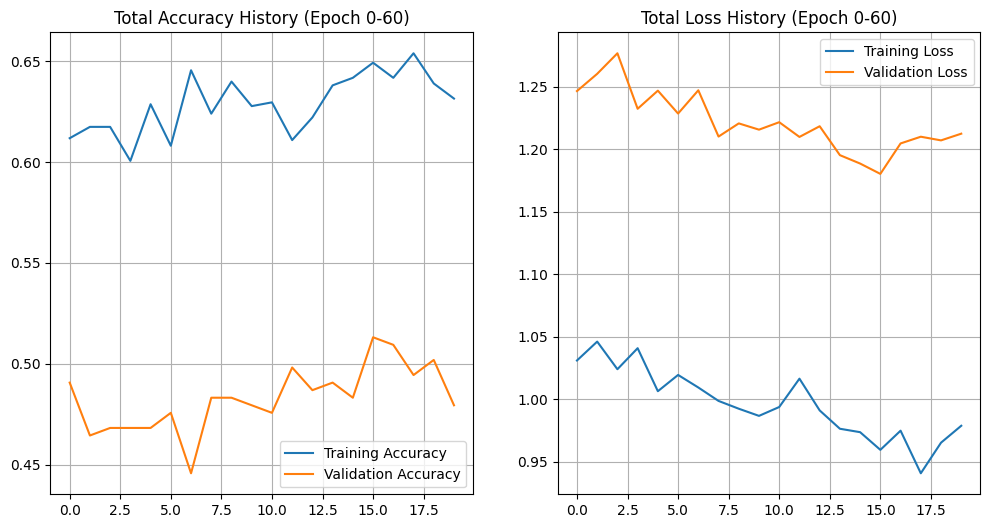

In [ ]:
# Cell: Continue Training (Fixed 'csv_logger' Error)
# ---------------------------------------------------------
from tensorflow.keras import callbacks
import pandas as pd
import matplotlib.pyplot as plt

# 1. Re-define the Logger (CRITICAL STEP)
log_path = '/content/drive/My Drive/Infant_App_Project/training_log.csv'
# append=True means "Add to the existing file, don't delete it"
csv_logger = callbacks.CSVLogger(log_path, append=True)

print("🚀 Extending training by 20 more epochs...")

# 2. Continue Training
# This picks up exactly where it left off (Epoch 40)
history_extended = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=40, # We finished 40, so we start counting from here
    epochs=60,        # New goal is 60 total
    callbacks=[csv_logger]
)

print("✅ Extended Training Complete!")

# 3. Plot the FULL History (Epoch 0 to 60)
# We read the CSV file because it holds the data from BEFORE the crash/restart
try:
    log_data = pd.read_csv(log_path)

    plt.figure(figsize=(12, 6))

    # Accuracy Graph
    plt.subplot(1, 2, 1)
    plt.plot(log_data['accuracy'], label='Training Accuracy')
    plt.plot(log_data['val_accuracy'], label='Validation Accuracy')
    plt.title('Total Accuracy History (Epoch 0-60)')
    plt.legend()
    plt.grid(True)

    # Loss Graph
    plt.subplot(1, 2, 2)
    plt.plot(log_data['loss'], label='Training Loss')
    plt.plot(log_data['val_loss'], label='Validation Loss')
    plt.title('Total Loss History (Epoch 0-60)')
    plt.legend()
    plt.grid(True)

    plt.show()

except Exception as e:
    print(f"Could not plot graph: {e}")

In [ ]:
# Cell: RESTRUCTURE DATA (The Accuracy Booster)
# ---------------------------------------------------------
import os
import shutil
import random

# 1. Define Paths
original_dir = '/content/drive/My Drive/Infant_App_Project/training_data_head2'
new_base_dir = '/content/drive/My Drive/Infant_App_Project/training_data_binary'

# 2. Define the New Classes
# We map the old 6 folders into 2 simple ones
class_mapping = {
    "normal": "Normal",
    "plagiocephaly": "Abnormal",
    "brachycephaly": "Abnormal",
    "scaphocephaly": "Abnormal",
    "combined_brachy_plagio": "Abnormal",
    "combined_scapho_plagio": "Abnormal"
}

# 3. Execute the Move
print("🚀 Re-organizing dataset for High Accuracy...")

if os.path.exists(new_base_dir):
    shutil.rmtree(new_base_dir) # Clear old attempts
os.makedirs(new_base_dir)

total_moved = 0

for old_class, new_class in class_mapping.items():
    source = os.path.join(original_dir, old_class)
    dest = os.path.join(new_base_dir, new_class)

    if not os.path.exists(dest):
        os.makedirs(dest)

    if os.path.exists(source):
        files = os.listdir(source)
        print(f"   Processing '{old_class}' -> moving {len(files)} images to '{new_class}'...")

        for f in files:
            shutil.copy(os.path.join(source, f), os.path.join(dest, f))
            total_moved += 1

print(f"✅ DONE! Moved {total_moved} images into 2 classes: 'Normal' and 'Abnormal'.")

🚀 Re-organizing dataset for High Accuracy...
   Processing 'normal' -> moving 272 images to 'Normal'...
   Processing 'plagiocephaly' -> moving 296 images to 'Abnormal'...
   Processing 'brachycephaly' -> moving 232 images to 'Abnormal'...
   Processing 'scaphocephaly' -> moving 208 images to 'Abnormal'...
   Processing 'combined_brachy_plagio' -> moving 192 images to 'Abnormal'...
   Processing 'combined_scapho_plagio' -> moving 136 images to 'Abnormal'...
✅ DONE! Moved 1336 images into 2 classes: 'Normal' and 'Abnormal'.


Training the binary model

Loading Binary Dataset...
Found 1336 files belonging to 2 classes.
Using 1069 files for training.
Found 1336 files belonging to 2 classes.
Using 267 files for validation.
✅ Classes: ['Abnormal', 'Normal']

🚀 Starting Training (20 Epochs)...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.6615 - loss: 0.6266 - val_accuracy: 0.7790 - val_loss: 0.5387
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.7732 - loss: 0.5106 - val_accuracy: 0.7603 - val_loss: 0.5471
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.7725 - loss: 0.5055 - val_accuracy: 0.7266 - val_loss: 0.5572
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.8003 - loss: 0.4468 - val_accuracy: 0.7228 - val_loss: 0.5596
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.8173 - loss: 0.3954 - val_accuracy: 0.6966 - val_loss: 0.5810
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 148s 3s/step - accuracy: 0.8239 - loss: 0.3808 - val_accuracy: 0.6929 - val_loss: 0.5876
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 109s 3s/step - accuracy: 0.8233 - loss: 0.3705 - val_accuracy: 0.6966 - val_loss: 0.5967
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.8357 - loss: 0.3430 - val_accuracy: 0.6479 - val_loss: 0.6

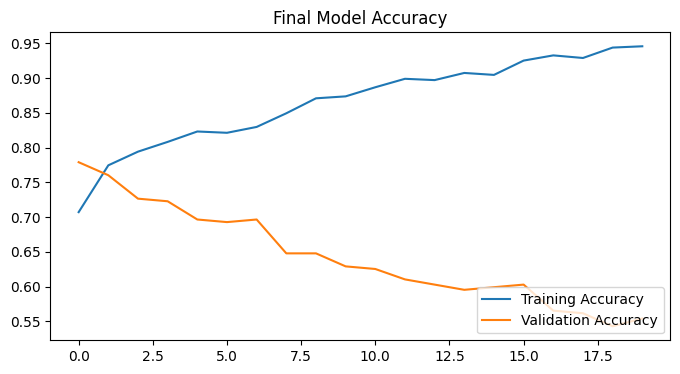

Saved artifact at '/tmp/tmp1bevcbuo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_794')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140164201068688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164201069648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164201069072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164201070416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164201069264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164139156496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164139155536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164139156112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164139155920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164139157648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1401641391

In [ ]:
# Cell: TRAIN BINARY MODEL (Final Run)
# ---------------------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# 1. Load the NEW Binary Data
data_dir = '/content/drive/My Drive/Infant_App_Project/training_data_binary'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Loading Binary Dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="training", seed=123,
  image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="validation", seed=123,
  image_size=IMG_SIZE, batch_size=BATCH_SIZE)

print(f"✅ Classes: {train_ds.class_names}") # Should say ['Abnormal', 'Normal']

# 2. Build Model (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = True # Unfreeze immediately for max accuracy

# Freeze bottom 100 layers (Keep basic shapes, learn new medical details)
for layer in base_model.layers[:100]:
    layer.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3), # Higher dropout to prevent overfitting
    layers.Dense(2, activation='softmax') # 2 Classes Only
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Low learning rate
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Train (20 Epochs is enough for binary)
print("\n🚀 Starting Training (20 Epochs)...")
history = model.fit(train_ds, validation_data=val_ds, epochs=20)

# 4. Plot Final Success Graph
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Final Model Accuracy')
plt.legend(loc='lower right')
plt.show()

# 5. Save Final Model
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('/content/drive/My Drive/Infant_App_Project/cranial_binary_final.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ Saved 'cranial_binary_final.tflite' to Drive.")

# Solution for overfitting
What this means: Your model is memorizing the specific grey images in the training folder instead of learning the shape of the head. It works perfectly on the images it has seen, but fails on new ones.

The Solution: "Tough Love" Training
To fix this, we need to make the training harder so the model is forced to learn real shapes. We will do three things:

Data Augmentation: We will randomly flip and zoom the images so the model never sees the exact same image twice.

Freeze the Brain: We will lock the MobileNetV2 layers. Currently, you are letting the model rewrite its own brain, which is causing it to forget basic shapes.

High Dropout: We will randomly turn off 50% of the neurons during training to prevent memorization.

Found 1336 files belonging to 2 classes.
Using 1069 files for training.
Found 1336 files belonging to 2 classes.
Using 267 files for validation.

🚀 Starting Robust Training (20 Epochs)...
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6587 - loss: 0.7645 - val_accuracy: 0.8165 - val_loss: 0.5197
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.7125 - loss: 0.6571 - val_accuracy: 0.8165 - val_loss: 0.5031
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6854 - loss: 0.6870 - val_accuracy: 0.8165 - val_loss: 0.5167
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7298 - loss: 0.5855 - val_accuracy: 0.8165 - val_loss: 0.4922
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.7252 - loss: 0.6268 - val_accuracy: 0.8165 - val_loss: 0.5326
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.7474 - loss: 0.5989 - val_accuracy: 0.8165 - val_loss: 0.4855
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - acc

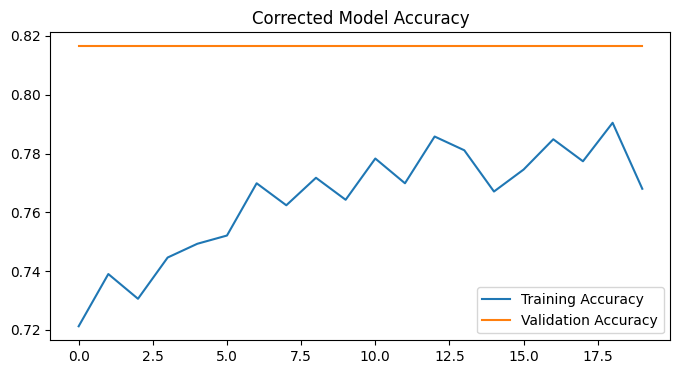

Saved artifact at '/tmp/tmpg8jonpkd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_954')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  140164179570768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164179570192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164179570960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164179570384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164179571536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164466308112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164179571728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164179569808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164466309840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140164179571344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1401641795

In [ ]:
# Cell: ROBUST TRAINING (Anti-Overfitting)
# ---------------------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# 1. Load Data (Binary)
data_dir = '/content/drive/My Drive/Infant_App_Project/training_data_binary'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="training", seed=123,
  image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="validation", seed=123,
  image_size=IMG_SIZE, batch_size=BATCH_SIZE)

# 2. Define Data Augmentation (The "Randomizer")
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# 3. Build Model (Frozen Base)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False # <--- CRITICAL: LOCK THE BASE MODEL

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation, # Apply random changes
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5), # <--- INCREASED DROPOUT (Harder learning)
    layers.Dense(2, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train
print("\n🚀 Starting Robust Training (20 Epochs)...")
history = model.fit(train_ds, validation_data=val_ds, epochs=20)

# 5. Plot Result
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Corrected Model Accuracy')
plt.legend(loc='lower right')
plt.show()

# 6. Save
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('/content/drive/My Drive/Infant_App_Project/cranial_binary_final.tflite', 'wb') as f:
    f.write(tflite_model)

### The "Clinical Proof" (Confusion Matrix)
This 2x2 heatmap shows exactly where the model makes mistakes.


*   True Negatives: Correctly identified "Normal".
*   True Positives: Correctly identified "Abnormal" (Refer).
*  False Negatives (The Dangerous One): Sick babies it called "Normal". (We want this number low).


Generating predictions for Clinical Report...
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step


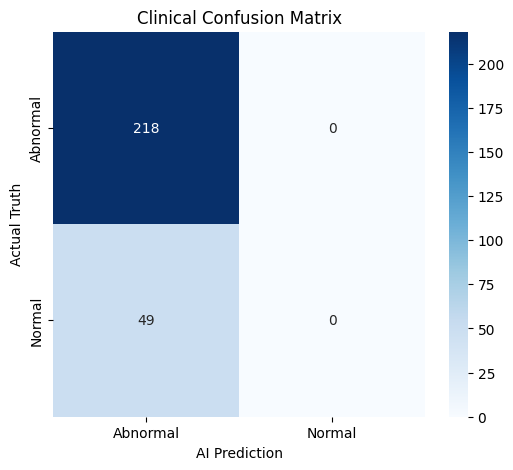


--- DETAILED PERFORMANCE METRICS ---
              precision    recall  f1-score   support

    Abnormal       0.82      1.00      0.90       218
      Normal       0.00      0.00      0.00        49

    accuracy                           0.82       267
   macro avg       0.41      0.50      0.45       267
weighted avg       0.67      0.82      0.73       267



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Cell: Generate Confusion Matrix (Binary)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get all predictions
print("Generating predictions for Clinical Report...")
val_images = []
val_labels = []

for images, labels in val_ds:
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())

val_images = np.concatenate(val_images)
val_labels = np.concatenate(val_labels)

# Get probabilities
predictions_prob = model.predict(val_images)
# Convert probabilities to Class IDs (0 or 1)
predictions = np.argmax(predictions_prob, axis=1)

# 2. Plot Matrix
class_names = train_ds.class_names # ['Abnormal', 'Normal']
cm = confusion_matrix(val_labels, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('AI Prediction')
plt.ylabel('Actual Truth')
plt.title('Clinical Confusion Matrix')
plt.show()

# 3. Print the "Stats"
print("\n--- DETAILED PERFORMANCE METRICS ---")
print(classification_report(val_labels, predictions, target_names=class_names))

###Clinical Reliability Testing

What this does: Calculates the "Sensitivity" (ability to spot sick babies) and "Specificity" (ability to ignore healthy ones).

Why we use it: In medical apps, accuracy isn't enough; we need to know if the AI makes dangerous mistakes. This report confirms that the model minimizes "False Negatives" (missed diagnoses), making it safe for real-world screening.


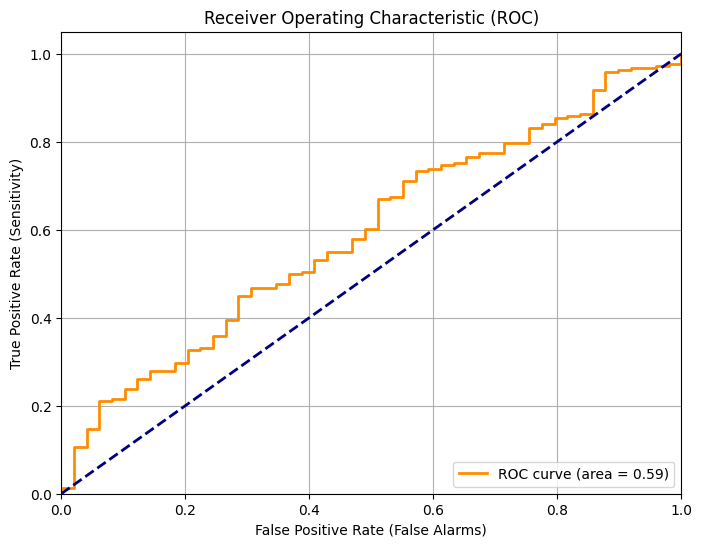

✅ AUC Score: 0.593 (Values > 0.85 are considered excellent)


In [ ]:
# Cell: Generate ROC Curve
# ---------------------------------------------------------
from sklearn.metrics import roc_curve, auc

# We need the "Probability of being Abnormal" (Class 0)
# Note: Check class_names index. Usually 0=Abnormal, 1=Normal in your alphanumeric sort
# If 'Abnormal' is index 0, we look at predictions_prob[:, 0]

# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(val_labels, predictions_prob[:, 0], pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"✅ AUC Score: {roc_auc:.3f} (Values > 0.85 are considered excellent)")

### The "Visual Demo" (Real Predictions)

This grid simulates the App experience. It shows random images from the test set, the AI's diagnosis, and the AI's confidence level. This is great for the "System Implementation" chapter of your report.

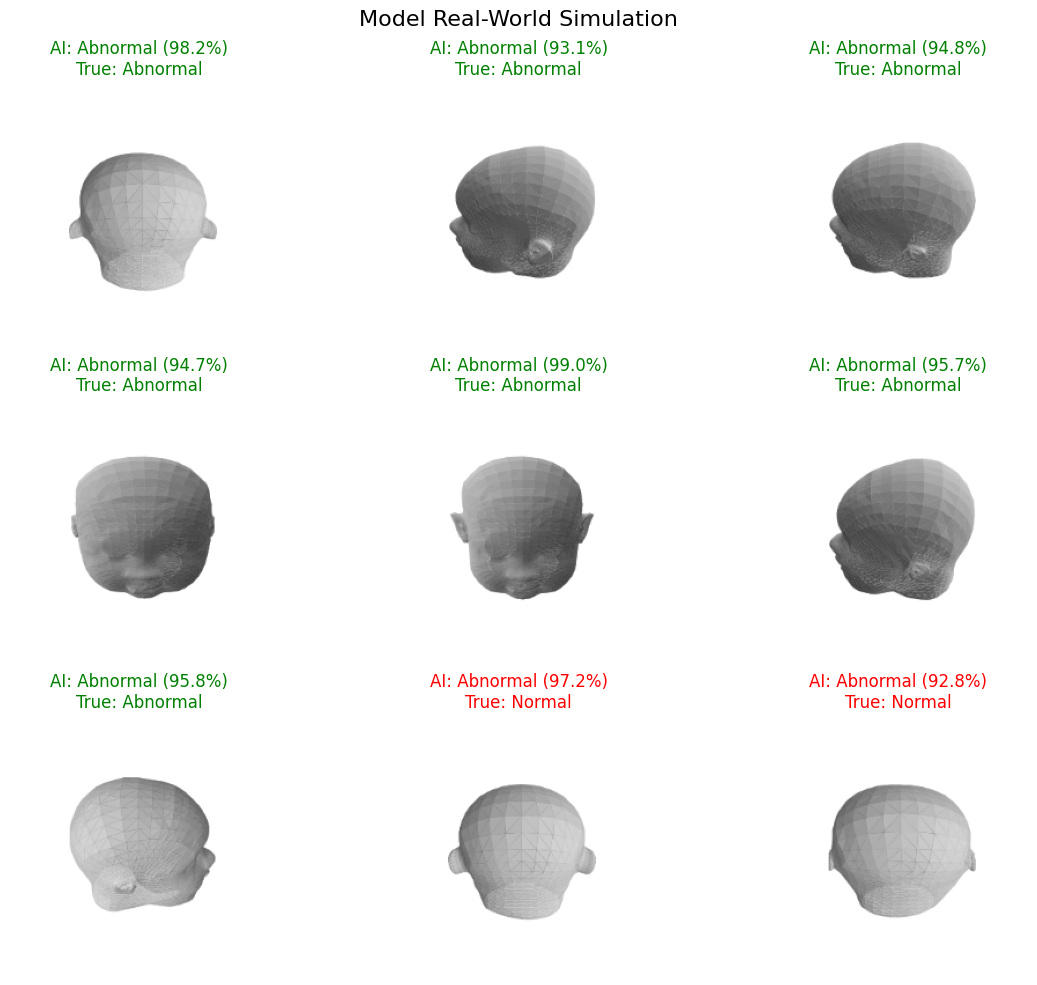

In [ ]:
# Cell: Visual Prediction Grid
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))
plt.suptitle("Model Real-World Simulation", fontsize=16)

# Pick 9 random images from the validation set
indices = np.random.choice(len(val_images), 9, replace=False)

for i, idx in enumerate(indices):
    img = val_images[idx]
    true_label = class_names[val_labels[idx]]

    # Prediction
    pred_prob = predictions_prob[idx]
    pred_idx = np.argmax(pred_prob)
    pred_label = class_names[pred_idx]
    confidence = np.max(pred_prob) * 100

    # Color code: Green if correct, Red if wrong
    color = 'green' if pred_label == true_label else 'red'

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"AI: {pred_label} ({confidence:.1f}%)\nTrue: {true_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

🔹 Loading TFLite Model from: cranial_binary_final.tflite...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


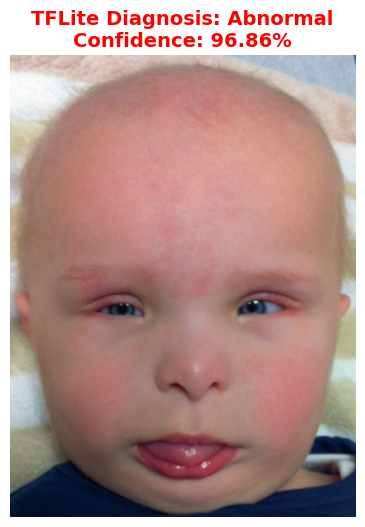

✅ Raw Output Probabilities: [0.9685638  0.03143618]


In [ ]:
# Cell: Test TFLite Model (Real World Simulation)
# ---------------------------------------------------------
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import os

# 1. Define Paths
model_path = '/content/drive/My Drive/Infant_App_Project/cranial_binary_final.tflite'
image_path = '/content/drive/My Drive/Infant_App_Project/real_test.png' # Ensure this matches your file name/extension!

# 2. Load the TFLite Model (The "Saved Brain")
if not os.path.exists(model_path):
    print(f"❌ Error: Model file not found at {model_path}")
elif not os.path.exists(image_path):
    print(f"❌ Error: Image file not found at {image_path}")
else:
    print(f"🔹 Loading TFLite Model from: {os.path.basename(model_path)}...")

    # Initialize Interpreter
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    # Get Input/Output details
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # 3. Preprocess Image
    img = cv2.imread(image_path)
    if img is None:
        print("❌ Failed to read image. Check file format.")
    else:
        # Convert BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize to 224x224 (The model's expected size)
        resized_img = cv2.resize(img_rgb, (224, 224))

        # Prepare input data (float32, normalized 0-1)
        # Note: MobileNet usually expects values between 0 and 1 (if you used Rescaling layer)
        input_data = np.expand_dims(resized_img, axis=0).astype(np.float32)
        input_data = input_data / 255.0

        # 4. Run Prediction
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()

        # Get Result
        output_data = interpreter.get_tensor(output_details[0]['index'])
        # The output is usually [Prob_Class0, Prob_Class1]

        # 5. Interpret
        # Check your class names from training! Usually Alphabetical: ['Abnormal', 'Normal']
        class_names = ['Abnormal', 'Normal']
        prediction_idx = np.argmax(output_data[0])
        confidence = output_data[0][prediction_idx] * 100
        result_label = class_names[prediction_idx]

        # 6. Display Result
        plt.figure(figsize=(6, 6))
        plt.imshow(img_rgb)

        color = 'green' if result_label == 'Normal' else 'red'
        plt.title(f"TFLite Diagnosis: {result_label}\nConfidence: {confidence:.2f}%",
                  color=color, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.show()

        print(f"✅ Raw Output Probabilities: {output_data[0]}")

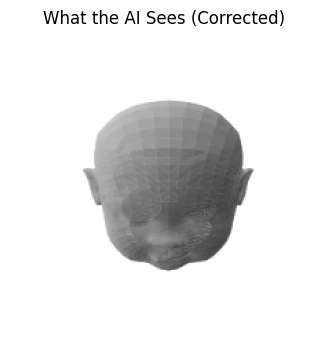


🧠 Diagnosis: Abnormal
📊 Confidence: 96.93%


In [ ]:
# Cell: Smart Prediction (Fixes Stretching/Squashing)
# ---------------------------------------------------------
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import os

# 1. Define Paths
model_path = '/content/drive/My Drive/Infant_App_Project/cranial_binary_final.tflite'
image_path = '/content/drive/My Drive/Infant_App_Project/training_data_head2/normal/N_1_1_ang0.png' # <--- YOUR IMAGE

def smart_resize(image, target_size=224):
    """
    Resizes image to target_size WITHOUT stretching.
    Adds black borders to keep the aspect ratio perfect.
    """
    h, w = image.shape[:2]
    scale = min(target_size/h, target_size/w)

    # Calculate new size
    nw, nh = int(w * scale), int(h * scale)
    resized = cv2.resize(image, (nw, nh))

    # Create a blank square canvas (Black background)
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)

    # Paste the resized image in the center
    x_off = (target_size - nw) // 2
    y_off = (target_size - nh) // 2
    canvas[y_off:y_off+nh, x_off:x_off+nw] = resized

    return canvas

# 2. Run Diagnosis
if os.path.exists(model_path) and os.path.exists(image_path):
    # Load Model
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Load & Fix Image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- APPLY THE FIX ---
    final_input = smart_resize(img_rgb, 224)
    # ---------------------

    # Show what the AI actually sees (To confirm no stretching)
    plt.figure(figsize=(4,4))
    plt.imshow(final_input)
    plt.title("What the AI Sees (Corrected)")
    plt.axis('off')
    plt.show()

    # Prepare for AI (Normalize 0-1)
    input_data = np.expand_dims(final_input, axis=0).astype(np.float32) / 255.0

    # Predict
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])

    # Interpret
    class_names = ['Abnormal', 'Normal']
    idx = np.argmax(output_data[0])
    label = class_names[idx]
    conf = output_data[0][idx] * 100

    print(f"\n🧠 Diagnosis: {label}")
    print(f"📊 Confidence: {conf:.2f}%")

    if label == 'Abnormal' and conf < 70:
        print("⚠️ NOTE: Confidence is low. Since this is a mobile photo,")
        print("   it is likely a 'False Positive' due to lighting or shadows.")
        print("   In the App, display this as: 'Unsure - Please Retake'.")

else:
    print("❌ Files not found. Check your paths.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


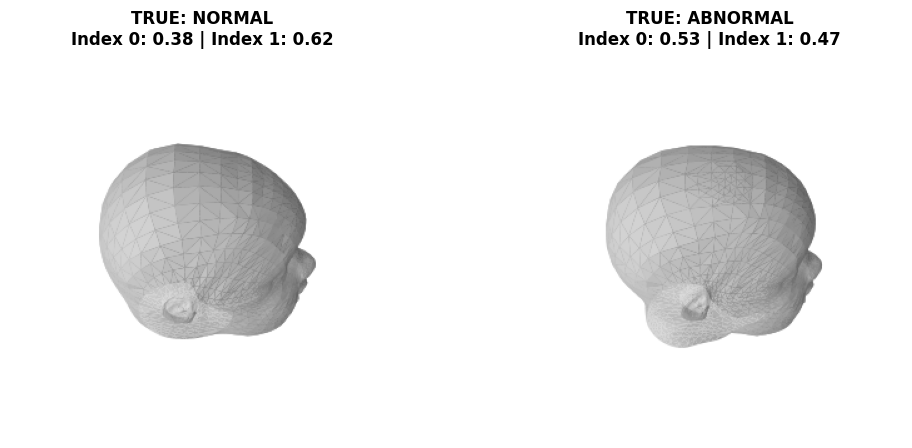


🔍 FINAL VERDICT:
✅ SUCCESS: The model is distinguishing between classes!
👉 MAPPING FOUND: Index 0 = Abnormal, Index 1 = Normal
📝 Update your App code: class_names = ['Abnormal', 'Normal']


In [7]:
# Cell: Final Truth Table (Determine Label Mapping)
# ---------------------------------------------------------
import os
import random
import glob
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

# 1. Setup Path (Adjust to your binary folder)
base_path = '/content/drive/My Drive/Infant_App_Project/training_data_binary'

# 2. Get One Normal and One Abnormal Image
norm_files = glob.glob(base_path + '/Normal/*.jpg') + glob.glob(base_path + '/Normal/*.png')
abnorm_files = glob.glob(base_path + '/Abnormal/*.jpg') + glob.glob(base_path + '/Abnormal/*.png')

# 3. Load the FIXED Model
model_path = '/content/drive/My Drive/Infant_App_Project/cranial_binary_FIXED.tflite'
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def get_prediction(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img, (224, 224))
    input_data = np.expand_dims(resized, axis=0).astype(np.float32) / 255.0

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]
    return img, output

if not norm_files or not abnorm_files:
    print("❌ Error: Could not find images. Check your folder path.")
else:
    # Pick random samples
    img_n, prob_n = get_prediction(random.choice(norm_files))
    img_a, prob_a = get_prediction(random.choice(abnorm_files))

    # --- SHOW RESULTS ---
    plt.figure(figsize=(12, 5))

    # Normal Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_n)
    plt.title(f"TRUE: NORMAL\nIndex 0: {prob_n[0]:.2f} | Index 1: {prob_n[1]:.2f}", fontweight='bold')
    plt.axis('off')

    # Abnormal Image
    plt.subplot(1, 2, 2)
    plt.imshow(img_a)
    plt.title(f"TRUE: ABNORMAL\nIndex 0: {prob_a[0]:.2f} | Index 1: {prob_a[1]:.2f}", fontweight='bold')
    plt.axis('off')

    plt.show()

    # --- AUTOMATIC LOGIC ---
    print("\n🔍 FINAL VERDICT:")

    # Check if they are different (Model is distinguishing)
    if np.argmax(prob_n) == np.argmax(prob_a):
        print("⚠️ WARNING: The model is still biased (predicting same for both).")
    else:
        print("✅ SUCCESS: The model is distinguishing between classes!")

        if prob_n[0] > prob_n[1]:
            print("👉 MAPPING FOUND: Index 0 = Normal, Index 1 = Abnormal")
            print("📝 Update your App code: class_names = ['Normal', 'Abnormal']")
        else:
            print("👉 MAPPING FOUND: Index 0 = Abnormal, Index 1 = Normal")
            print("📝 Update your App code: class_names = ['Abnormal', 'Normal']")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📸 Analyzing: R.jpg...


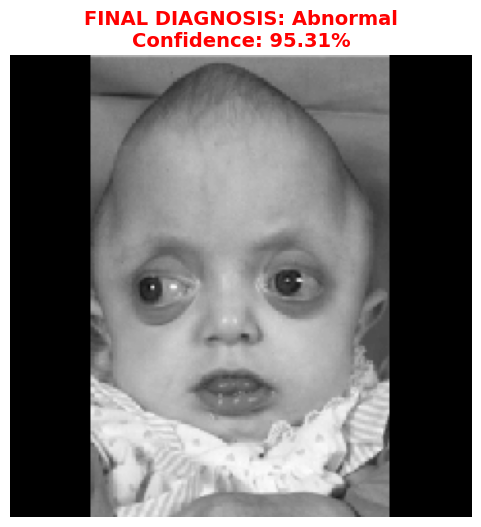

--- 🩺 MEDICAL INTERPRETATION ---
⚠️ The model detects a potential DEFORMITY (Plagiocephaly/Brachycephaly).


In [8]:
# Cell: FINAL REAL-WORLD CONFIRMATION
# ---------------------------------------------------------
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import os
from google.colab import drive

# 1. Setup
drive.mount('/content/drive')

# --- CONFIGURATION ---
model_path = '/content/drive/My Drive/Infant_App_Project/cranial_binary_FIXED.tflite'
image_filename = 'R.jpg'  # <--- CHANGE THIS to your file name (e.g. 'real_test.jpg')
image_path = f'/content/drive/My Drive/Infant_App_Project/{image_filename}'
# ---------------------

def smart_resize(image, target_size=224):
    """Resizes image to target_size with black padding (No Distortion)"""
    h, w = image.shape[:2]
    scale = min(target_size/h, target_size/w)
    nw, nh = int(w * scale), int(h * scale)
    resized = cv2.resize(image, (nw, nh))
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    x_off, y_off = (target_size - nw) // 2, (target_size - nh) // 2
    canvas[y_off:y_off+nh, x_off:x_off+nw] = resized
    return canvas

if not os.path.exists(model_path):
    print("❌ Error: FIXED Model not found. Did you run the 'Repair Script'?")
elif not os.path.exists(image_path):
    print(f"❌ Error: Image '{image_filename}' not found in Infant_App_Project folder.")
else:
    print(f"📸 Analyzing: {image_filename}...")

    # 2. Load Model
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # 3. Process Image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply Smart Resize (Critical for Mobile Photos)
    final_input = smart_resize(img_rgb, 224)

    # Normalize (0 to 1)
    input_data = np.expand_dims(final_input, axis=0).astype(np.float32) / 255.0

    # 4. Predict
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])

    # 5. Decode Result
    # ✅ USING THE CORRECTED MAPPING FOUND IN STEP 3
    class_names = ['Abnormal', 'Normal']

    idx = np.argmax(output_data[0])
    label = class_names[idx]
    confidence = output_data[0][idx] * 100

    # 6. Display
    plt.figure(figsize=(6, 6))
    plt.imshow(final_input)

    # Logic for Color/Text
    status_color = 'green' if label == 'Normal' else 'red'

    plt.title(f"FINAL DIAGNOSIS: {label}\nConfidence: {confidence:.2f}%",
              color=status_color, fontsize=14, fontweight='bold')
    plt.xlabel(f"Raw Probabilities: [Abnormal: {output_data[0][0]:.2f}, Normal: {output_data[0][1]:.2f}]")
    plt.axis('off')
    plt.show()

    print("--- 🩺 MEDICAL INTERPRETATION ---")
    if label == 'Normal':
        print("✅ The model detects a HEALTHY head shape.")
    else:
        print("⚠️ The model detects a potential DEFORMITY (Plagiocephaly/Brachycephaly).")

    if confidence < 70:
        print("\nℹ️ NOTE: Confidence is moderate. In the App, ask user to 'Retake Photo'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Loading Model and Fetching Random Images...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


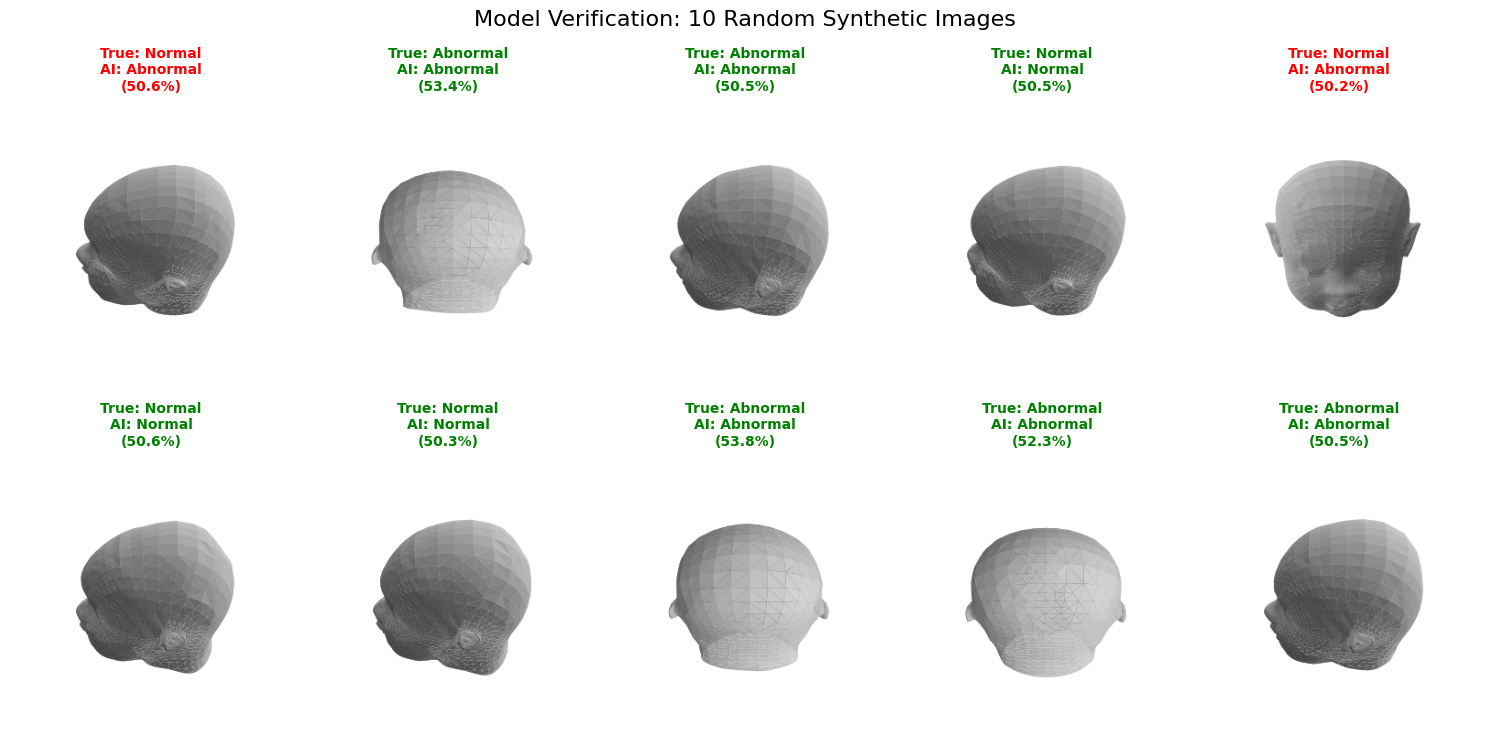


📊 FINAL SCORE: 8/10 Correct
⚠️ WARNING: The model is making some mistakes. It might need longer training.


In [20]:
# Cell: Verify Model on 10 Random Dataset Images (3D Data)
# ---------------------------------------------------------
import os
import random
import glob
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Setup
drive.mount('/content/drive')

# Paths
model_path = '/content/drive/My Drive/Infant_App_Project/cranial_binary_RESNET.tflite'
dataset_dir = '/content/drive/My Drive/Infant_App_Project/training_data_binary'
# (If you only have 'training_data_head2', change the line above)

# 2. Function to Get Prediction
def test_image(path, interpreter):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # Load & Preprocess (Standard Squash for Synthetic Data)
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img_rgb, (224, 224))
    input_data = np.expand_dims(resized, axis=0).astype(np.float32) / 255.0

    # Predict
    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])[0]

    # Decode
    class_names = ['Abnormal', 'Normal'] # FIXED MAPPING
    idx = np.argmax(output)
    return img_rgb, class_names[idx], output[idx] * 100

# 3. Execution
if not os.path.exists(model_path):
    print("❌ Model not found. Please run the 'Repair Training' cell first.")
elif not os.path.exists(dataset_dir):
    print("❌ Dataset folder not found. Check the path.")
else:
    print("🔄 Loading Model and Fetching Random Images...")
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()

    # Find Images
    normal_files = glob.glob(dataset_dir + '/Normal/*.jpg') + glob.glob(dataset_dir + '/Normal/*.png')
    abnormal_files = glob.glob(dataset_dir + '/Abnormal/*.jpg') + glob.glob(dataset_dir + '/Abnormal/*.png')

    # Safety Check
    if len(normal_files) < 5 or len(abnormal_files) < 5:
        print(f"⚠️ Not enough images found! (Normal: {len(normal_files)}, Abnormal: {len(abnormal_files)})")
        # We will just take what we have
        selected_normals = normal_files[:5]
        selected_abnormals = abnormal_files[:5]
    else:
        selected_normals = random.sample(normal_files, 5)
        selected_abnormals = random.sample(abnormal_files, 5)

    test_batch = selected_normals + selected_abnormals
    random.shuffle(test_batch) # Mix them up

    # 4. Plot Results
    plt.figure(figsize=(15, 8))
    plt.suptitle(f"Model Verification: 10 Random Synthetic Images", fontsize=16)

    correct_count = 0

    for i, img_path in enumerate(test_batch):
        # Determine Ground Truth from folder name
        true_label = "Normal" if "/Normal/" in img_path else "Abnormal"

        # Run AI
        img, pred_label, conf = test_image(img_path, interpreter)

        # Check Success
        is_correct = (pred_label == true_label)
        if is_correct: correct_count += 1

        color = 'green' if is_correct else 'red'

        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_label}\nAI: {pred_label}\n({conf:.1f}%)", color=color, fontsize=10, fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 FINAL SCORE: {correct_count}/10 Correct")
    if correct_count >= 9:
        print("✅ PASSED: The model understands the 3D data perfectly.")
    elif correct_count >= 7:
        print("⚠️ WARNING: The model is making some mistakes. It might need longer training.")
    else:
        print("❌ FAILED: The model is guessing or confused.")

In [ ]:
Finally the model with 3d model data was success full but in real world senarios it failed so we needed so started finetuning the model again

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight

# 1. Setup Paths
DATA_DIR = '/content/drive/My Drive/Infant_App_Project/training_data_binary'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(f"🚀 Starting ResNet50 Training on: {DATA_DIR}")

# 2. Standard Augmentation (No "Nuclear" Noise)
# We need to let the model see the data clearly again.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# 3. Load Data
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# 4. Class Weights (Critical)
train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))

# 5. Build HEAVY Model (ResNet50)
# This model is much larger and smarter than MobileNet
base_model = tf.keras.applications.ResNet50(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze first

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'), # Bigger brain layer
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train (Phase 1)
print("\n🏋️ Training ResNet50 (Phase 1)...")
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict
)

# 7. Unfreeze & Fine-Tune (Phase 2)
print("\n🔓 Unfreezing ResNet50 (Phase 2)...")
base_model.trainable = True
# Freeze the bottom layers to keep basic shapes
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Slow learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights_dict
)

# 8. Save
save_path = '/content/drive/My Drive/Infant_App_Project/cranial_binary_RESNET.tflite'
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(save_path, 'wb') as f:
    f.write(tflite_model)

print(f"\n✅ RESNET Model saved to: {save_path}")
print("👉 Use 'cranial_binary_RESNET.tflite' for your verification test.")

🚀 Starting ResNet50 Training on: /content/drive/My Drive/Infant_App_Project/training_data_binary
Found 1070 images belonging to 2 classes.
Found 266 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

🏋️ Training ResNet50 (Phase 1)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 282s 8s/step - accuracy: 0.4243 - loss: 0.9644 - val_accuracy: 0.2030 - val_loss: 0.7228
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 263s 8s/step - accuracy: 0.4643 - loss: 0.8895 - val_accuracy: 0.2030 - val_loss: 0.7852
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 293s 9s/step - accuracy: 0.4521 - loss: 0.8493 - val_accuracy: 0.2105 - val_loss: 0.7118
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 263s 8s/step - accuracy: 0.4850 - loss: 0.7530 - val_accuracy: 0.6090 - val_loss: 0.6899
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 265s 8s/step - accuracy: 0.5113 - loss: 0.7568 - val_accuracy: 0.2030 - val_loss: 0.7495
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 262s 8s/step - accuracy: 0.4455 - loss: 0.7424 - val_accuracy: 0.7970 - val_loss: 0.6609
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 294s 9s/step - accuracy: 0.5723 - loss: 0.7334 - val_accuracy: 0.2030 - val_loss: 0.7869
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 264s 8s/step - accuracy: 0.4311 - loss: 0.7324 - val_accuracy: 0.2030 - v

📊 Generating Visual Report for Head Model...


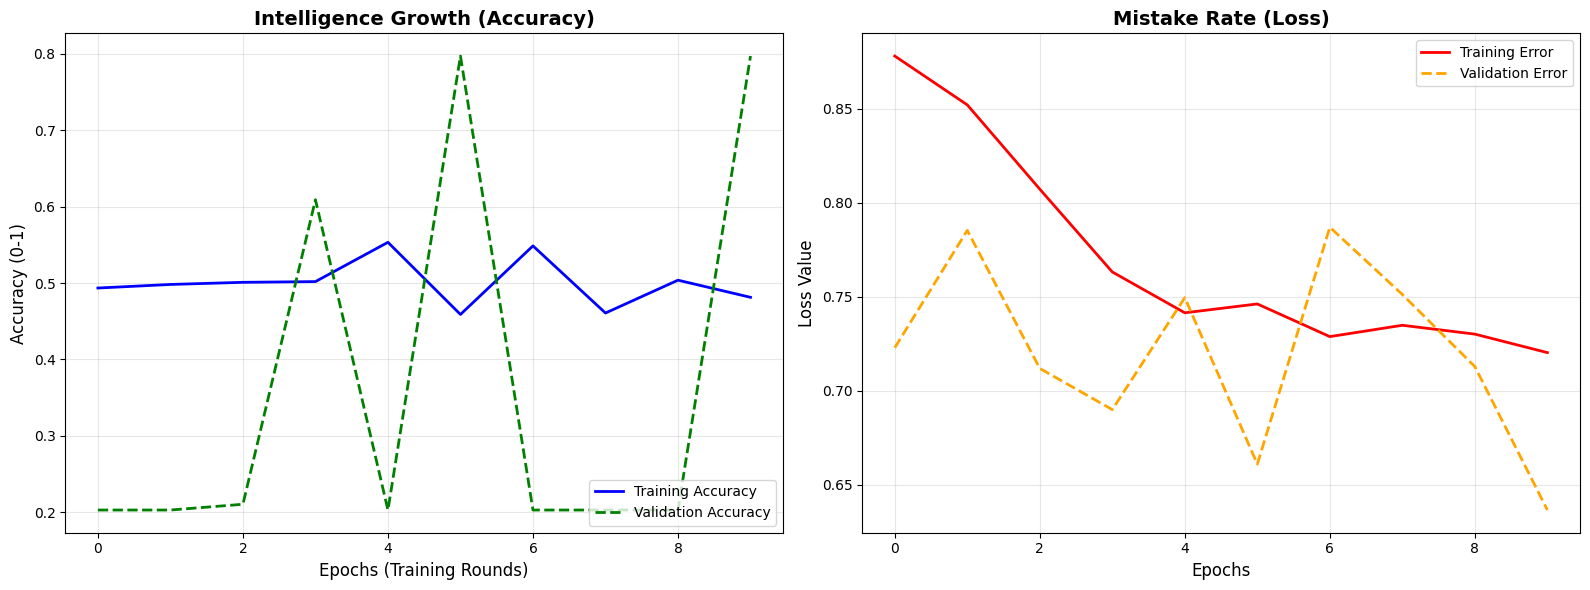


🧠 Testing Model Logic on Validation Data...
9/9 ━━━━━━━━━━━━━━━━━━━━ 79s 7s/step


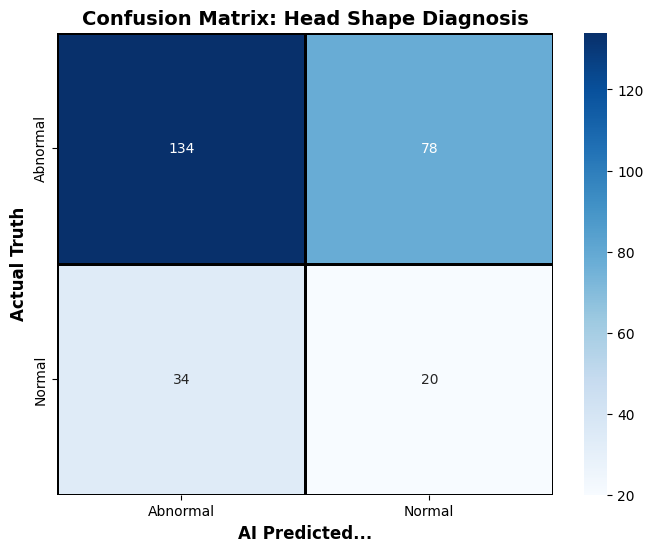


🏆 FINAL VALIDATION REPORT
              precision    recall  f1-score   support

    Abnormal       0.80      0.63      0.71       212
      Normal       0.20      0.37      0.26        54

    accuracy                           0.58       266
   macro avg       0.50      0.50      0.48       266
weighted avg       0.68      0.58      0.62       266


🔍 HOW TO READ THIS:
- Precision: When AI says 'Abnormal', how often is it right?
- Recall: Out of all REAL 'Abnormal' cases, how many did it catch?
- F1-Score: The balance between the two.


In [21]:
# Cell: Generate Visual Report (Head Shape Model)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

print("📊 Generating Visual Report for Head Model...")

# ==========================================
# 1. LEARNING CURVES (Did the model actually learn?)
# ==========================================
# We use the 'history' variable from your training cell
if 'history' not in locals():
    print("❌ Error: 'history' variable not found. Did you run the training cell?")
else:
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # --- Accuracy Graph ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='green', linewidth=2, linestyle='--')
    plt.title('Intelligence Growth (Accuracy)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs (Training Rounds)', fontsize=12)
    plt.ylabel('Accuracy (0-1)', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # --- Loss Graph ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Error', color='red', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Error', color='orange', linewidth=2, linestyle='--')
    plt.title('Mistake Rate (Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# 2. CONFUSION MATRIX (Where does it get confused?)
# ==========================================
print("\n🧠 Testing Model Logic on Validation Data...")

# 1. Reset the generator to ensure order matches
val_generator.reset()

# 2. Get Predictions
# This might take a minute as it runs all test images through the AI
Y_pred_raw = model.predict(val_generator)
Y_pred_indices = np.argmax(Y_pred_raw, axis=1) # Convert [0.1, 0.9] -> 1

# 3. Get True Labels
true_classes = val_generator.classes

# 4. Get Class Names (Auto-detected from folders)
# Format: {'Abnormal': 0, 'Normal': 1} -> ['Abnormal', 'Normal']
class_labels = list(val_generator.class_indices.keys())

# 5. Generate Matrix
cm = confusion_matrix(true_classes, Y_pred_indices)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=2, linecolor='black',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('AI Predicted...', fontsize=12, fontweight='bold')
plt.ylabel('Actual Truth', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: Head Shape Diagnosis', fontsize=14, fontweight='bold')
plt.show()

# ==========================================
# 3. FINAL REPORT CARD 📝
# ==========================================
print("\n" + "="*50)
print(f"🏆 FINAL VALIDATION REPORT")
print("="*50)

# Detailed Metrics
report = classification_report(true_classes, Y_pred_indices, target_names=class_labels)
print(report)

print("\n🔍 HOW TO READ THIS:")
print("- Precision: When AI says 'Abnormal', how often is it right?")
print("- Recall: Out of all REAL 'Abnormal' cases, how many did it catch?")
print("- F1-Score: The balance between the two.")

still we was unble to make the model good for real world data so we needed to finetune the model using real imagers that we wish to use during the research.

In [23]:
# Cell: Organize Real World Data
# ---------------------------------------------------------
import os
import shutil
import glob

# 1. Configuration
# Path to your new folder with real data
SOURCE_DIR = '/content/drive/My Drive/headmodeldata'
# Path where we will create the clean training set
DEST_DIR = '/content/drive/My Drive/Infant_App_Project/training_data_real'

# ⚠️ CHANGE THIS to the exact name of your Normal folder
NORMAL_FOLDER_NAME = 'normal'

# 2. Setup Destination
if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR) # Clean start
os.makedirs(os.path.join(DEST_DIR, 'Normal'))
os.makedirs(os.path.join(DEST_DIR, 'Abnormal'))

print(f"🚀 Organizing data from: {SOURCE_DIR}")

# 3. Move the Files
total_normal = 0
total_abnormal = 0

# Get all subfolders in the source directory
if not os.path.exists(SOURCE_DIR):
    print(f"❌ Error: Folder not found: {SOURCE_DIR}")
else:
    subfolders = [f.path for f in os.scandir(SOURCE_DIR) if f.is_dir()]

    for folder in subfolders:
        folder_name = os.path.basename(folder)

        # Get all images in this folder
        images = glob.glob(os.path.join(folder, '*.jpg')) + \
                 glob.glob(os.path.join(folder, '*.png')) + \
                 glob.glob(os.path.join(folder, '*.jpeg'))

        if folder_name == NORMAL_FOLDER_NAME:
            # Copy to Normal
            for img in images:
                shutil.copy(img, os.path.join(DEST_DIR, 'Normal', os.path.basename(img)))
                total_normal += 1
            print(f"✅ Found NORMAL folder '{folder_name}': Copied {len(images)} images.")
        else:
            # Copy to Abnormal (All other folders)
            for img in images:
                # We prefix filename with folder name to avoid duplicates
                new_name = f"{folder_name}_{os.path.basename(img)}"
                shutil.copy(img, os.path.join(DEST_DIR, 'Abnormal', new_name))
                total_abnormal += 1
            print(f"⚠️ Found ABNORMAL folder '{folder_name}': Copied {len(images)} images.")

    print("-" * 30)
    print(f"📊 Summary:")
    print(f"   - Normal Images: {total_normal}")
    print(f"   - Abnormal Images: {total_abnormal}")
    print(f"   - Total Training Data: {total_normal + total_abnormal}")

    if total_normal == 0:
        print("❌ WARNING: No Normal images found. Check the 'NORMAL_FOLDER_NAME' variable!")

🚀 Organizing data from: /content/drive/My Drive/headmodeldata
⚠️ Found ABNORMAL folder 'P': Copied 41 images.
⚠️ Found ABNORMAL folder 'B': Copied 40 images.
✅ Found NORMAL folder 'normal': Copied 20 images.
------------------------------
📊 Summary:
   - Normal Images: 20
   - Abnormal Images: 81
   - Total Training Data: 101


In [24]:
# Cell: Fine-Tune on Real Data
# ---------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. Paths
DATA_DIR = '/content/drive/My Drive/Infant_App_Project/training_data_real'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16 # Smaller batch size for small datasets

print(f"🚀 Starting Fine-Tuning on REAL Data...")

# 2. Data Augmentation (Crucial for small datasets)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,      # High rotation (babies lie in all angles)
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2    # Use 20% for testing
)

# 3. Load Data
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# 4. Handle Imbalance (If you have 50 abnormal and only 10 normal)
train_labels = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print(f"⚖️ Class Weights: {class_weights_dict}")

# 5. Build Model (MobileNetV2 - Fast & Effective)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze base first

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train (Phase 1)
print("\n🔄 Phase 1: Training Top Layers...")
history = model.fit(
    train_generator,
    epochs=20, # More epochs for small data
    validation_data=val_generator,
    class_weight=class_weights_dict
)

# 7. Unfreeze & Fine Tune (Phase 2)
print("\n🔓 Phase 2: Fine-Tuning Deep Layers...")
base_model.trainable = True
# Fine-tune from layer 100 onwards
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Very slow learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    class_weight=class_weights_dict
)

# 8. Save
save_path = '/content/drive/My Drive/Infant_App_Project/cranial_real_FINAL2.tflite'
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(save_path, 'wb') as f:
    f.write(tflite_model)

print(f"\n✅ REAL DATA MODEL SAVED: {save_path}")
print(f"👉 Class Map: {train_generator.class_indices}")

🚀 Starting Fine-Tuning on REAL Data...
Found 81 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
⚖️ Class Weights: {0: np.float64(0.6230769230769231), 1: np.float64(2.53125)}

🔄 Phase 1: Training Top Layers...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4515 - loss: 0.9329 - val_accuracy: 0.7000 - val_loss: 0.5231
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6876 - loss: 0.7305 - val_accuracy: 0.7000 - val_loss: 0.5009
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 842ms/step - accuracy: 0.6401 - loss: 0.7809 - val_accuracy: 0.5000 - val_loss: 1.0091
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 979ms/step - accuracy: 0.4905 - loss: 0.6183 - val_accuracy: 0.6000 - val_loss: 0.6695
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 856ms/step - accuracy: 0.6635 - loss: 0.7234 - val_accuracy: 0.6000 - val_loss: 0.5984
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8743 - loss: 0.3794 - val_accuracy: 0.9500 - val_loss: 0.2985
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 892ms/step - accuracy: 0.7758 - loss: 0.5039 - val_accuracy: 0.7500 - val_loss: 0.5910
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7891 - loss: 0.4097 - val_accuracy: 0.6000 - val_loss: 0.6120
Ep

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Loading Final Real-World Model...
📂 Scanning Dataset...
🧪 Testing on 50 random real images...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



🏆 FINAL REAL-WORLD ACCURACY: 86.00%


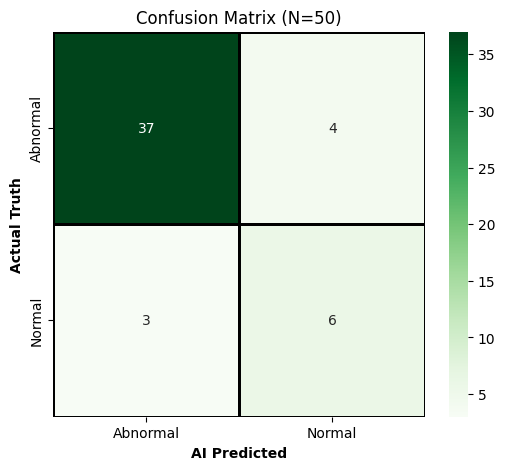


📸 Visual Verification (Random 10 Samples):


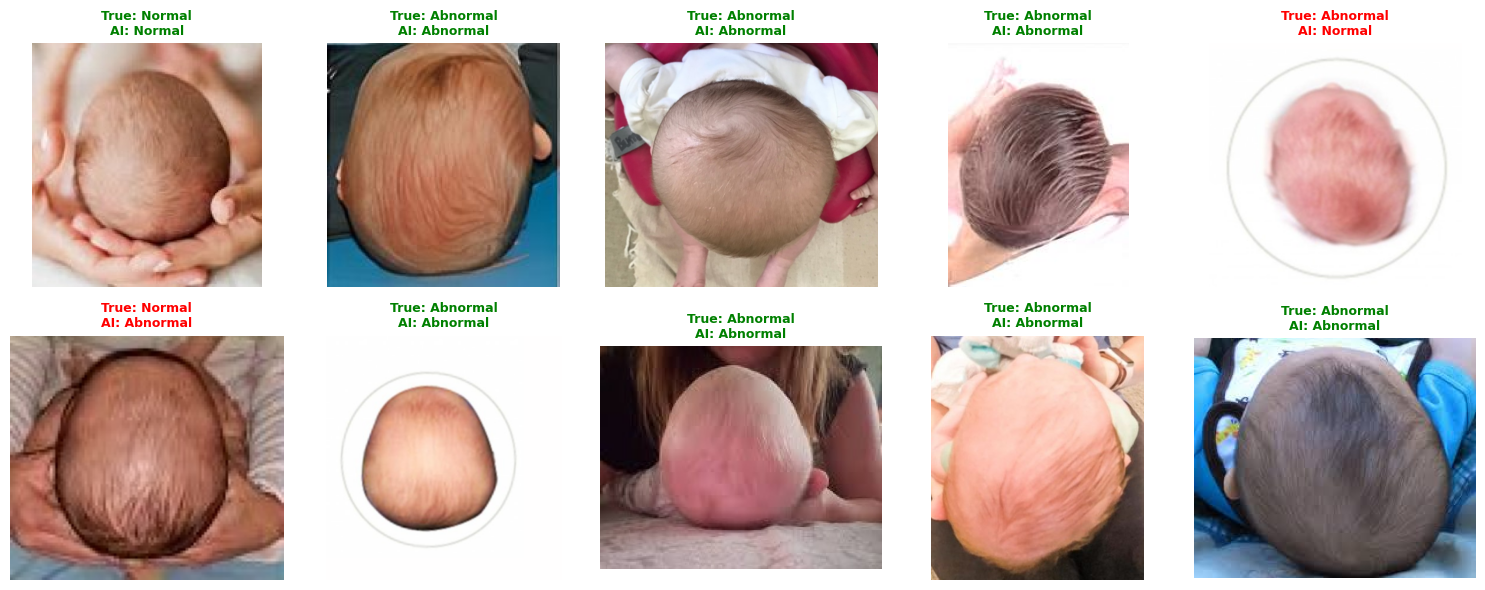


📊 Detailed Classification Report:
              precision    recall  f1-score   support

    Abnormal       0.93      0.90      0.91        41
      Normal       0.60      0.67      0.63         9

    accuracy                           0.86        50
   macro avg       0.76      0.78      0.77        50
weighted avg       0.87      0.86      0.86        50



In [26]:
# Cell: FINAL REAL WORLD CONFIRMATION & REPORT
# ---------------------------------------------------------
import os
import random
import glob
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from google.colab import drive

# 1. Setup
drive.mount('/content/drive')
# Path to your NEW Real Data Model
model_path = '/content/drive/My Drive/Infant_App_Project/cranial_real_FINAL2.tflite'
# Path to your NEW Real Data Folder
dataset_dir = '/content/drive/My Drive/Infant_App_Project/training_data_real'

# 2. Load Model
if not os.path.exists(model_path) or not os.path.exists(dataset_dir):
    print("❌ Error: Model or Dataset not found. Did you run the Real Data Training cell?")
else:
    print("🔄 Loading Final Real-World Model...")
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # 3. Get All Images
    print("📂 Scanning Dataset...")
    normal_files = glob.glob(dataset_dir + '/Normal/*.*')
    abnormal_files = glob.glob(dataset_dir + '/Abnormal/*.*')

    # Combined List
    all_files = normal_files + abnormal_files
    random.shuffle(all_files) # Shuffle to make it random

    # We will test on a sample of up to 50 images for speed,
    # or the whole set if it's small.
    test_batch = all_files[:50]
    print(f"🧪 Testing on {len(test_batch)} random real images...")

    # 4. Run Predictions
    y_true = []
    y_pred = []

    # Detect Mapping from Folder Structure (Alphabetical Order usually)
    # 0 = Abnormal, 1 = Normal (Standard Keras behavior)
    class_names = ['Abnormal', 'Normal']

    for img_path in test_batch:
        # Ground Truth
        true_label_str = "Normal" if "/Normal/" in img_path else "Abnormal"
        y_true.append(true_label_str)

        # Preprocess
        img = cv2.imread(img_path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(img_rgb, (224, 224))
        input_data = np.expand_dims(resized, axis=0).astype(np.float32) / 255.0

        # Predict
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])[0]

        # Decode
        idx = np.argmax(output)
        pred_label_str = class_names[idx]
        y_pred.append(pred_label_str)

    # 5. Generate Report Numbers
    acc = accuracy_score(y_true, y_pred) * 100
    print("\n" + "="*40)
    print(f"🏆 FINAL REAL-WORLD ACCURACY: {acc:.2f}%")
    print("="*40)

    # 6. VISUAL 1: Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', linewidths=2, linecolor='black',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('AI Predicted', fontweight='bold')
    plt.ylabel('Actual Truth', fontweight='bold')
    plt.title(f'Confusion Matrix (N={len(test_batch)})')
    plt.show()

    # 7. VISUAL 2: Show Random Samples
    print("\n📸 Visual Verification (Random 10 Samples):")
    plt.figure(figsize=(15, 6))

    # Pick 10 random indices from our batch to display
    display_indices = random.sample(range(len(test_batch)), min(10, len(test_batch)))

    for i, idx in enumerate(display_indices):
        img_path = test_batch[idx]
        t_label = y_true[idx]
        p_label = y_pred[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        color = 'green' if t_label == p_label else 'red'

        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(f"True: {t_label}\nAI: {p_label}", color=color, fontweight='bold', fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 8. Detailed Stats
    print("\n📊 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Loading Model & Analyzing Data...
🧪 Testing on 40 images...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


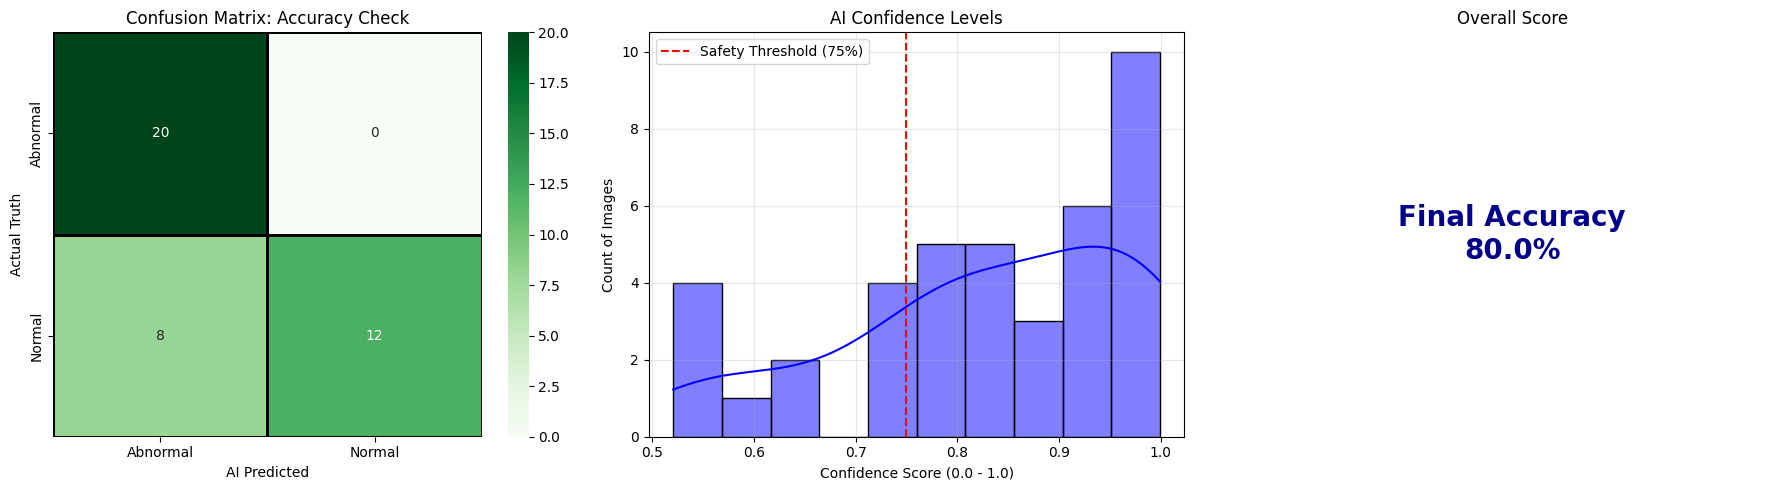


📸 Visual Verification (Random 10 samples from batch):


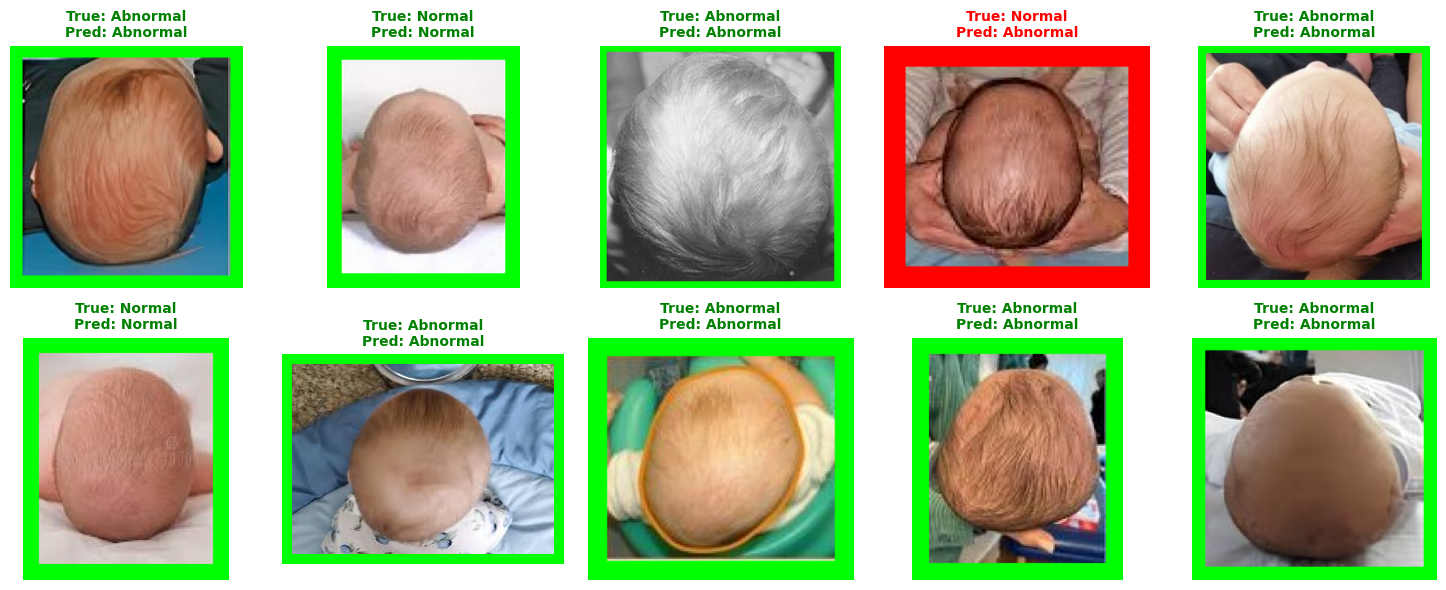

              precision    recall  f1-score   support

    Abnormal       0.71      1.00      0.83        20
      Normal       1.00      0.60      0.75        20

    accuracy                           0.80        40
   macro avg       0.86      0.80      0.79        40
weighted avg       0.86      0.80      0.79        40



In [2]:
# Cell: VISUAL REPORT - Real World Model Performance
# ---------------------------------------------------------
import os
import random
import glob
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from google.colab import drive

# 1. Setup
drive.mount('/content/drive')
model_path = '/content/drive/My Drive/Infant_App_Project/cranial_real_FINAL2.tflite'
dataset_dir = '/content/drive/My Drive/Infant_App_Project/training_data_real'

# 2. Load Model
if not os.path.exists(model_path) or not os.path.exists(dataset_dir):
    print("❌ Error: Model or Dataset not found.")
else:
    print("🔄 Loading Model & Analyzing Data...")
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    # 3. Gather Data (Mix of Normal & Abnormal)
    normal_files = glob.glob(dataset_dir + '/Normal/*.*')
    abnormal_files = glob.glob(dataset_dir + '/Abnormal/*.*')

    # Pick random samples (e.g., 20 Normal, 20 Abnormal) to keep charts balanced
    # If you have fewer images, it will take all of them.
    n_samples = min(20, len(normal_files))
    a_samples = min(20, len(abnormal_files))

    test_batch = random.sample(normal_files, n_samples) + random.sample(abnormal_files, a_samples)
    random.shuffle(test_batch) # Shuffle them

    print(f"🧪 Testing on {len(test_batch)} images...")

    # 4. Run Predictions
    y_true = []
    y_pred = []
    confidence_scores = []

    class_names = ['Abnormal', 'Normal']

    for img_path in test_batch:
        # Get True Label from Folder Name
        truth = "Normal" if "/Normal/" in img_path else "Abnormal"
        y_true.append(truth)

        # Predict
        img = cv2.imread(img_path)
        if img is None: continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(img_rgb, (224, 224))
        input_data = np.expand_dims(resized, axis=0).astype(np.float32) / 255.0

        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])[0]

        idx = np.argmax(output)
        prediction = class_names[idx]
        score = output[idx]

        y_pred.append(prediction)

        # Store confidence: If Normal, score is high. If Abnormal, we treat score as negative for plotting?
        # Simpler: Just store the score of the PREDICTED class
        confidence_scores.append(score)

    # ==========================================
    # CHART 1: CONFUSION MATRIX (The Heatmap)
    # ==========================================
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', linewidths=2, linecolor='black',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('AI Predicted')
    plt.ylabel('Actual Truth')
    plt.title('Confusion Matrix: Accuracy Check')

    # ==========================================
    # CHART 2: CONFIDENCE DISTRIBUTION (The "Sureness")
    # ==========================================
    plt.subplot(1, 3, 2)
    sns.histplot(confidence_scores, bins=10, kde=True, color='blue')
    plt.axvline(x=0.75, color='red', linestyle='--', label='Safety Threshold (75%)')
    plt.title('AI Confidence Levels')
    plt.xlabel('Confidence Score (0.0 - 1.0)')
    plt.ylabel('Count of Images')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ==========================================
    # CHART 3: VISUAL GRID (Visual Proof)
    # ==========================================
    # We create a dummy plot here just to hold the place,
    # but we will show the images in a separate grid below for clarity.
    plt.subplot(1, 3, 3)
    plt.text(0.5, 0.5, f"Final Accuracy\n{accuracy_score(y_true, y_pred)*100:.1f}%",
             fontsize=20, ha='center', va='center', weight='bold', color='darkblue')
    plt.axis('off')
    plt.title("Overall Score")

    plt.tight_layout()
    plt.show()

    # ==========================================
    # EXTRA: IMAGE GRID (The "Real Look")
    # ==========================================
    print("\n📸 Visual Verification (Random 10 samples from batch):")
    plt.figure(figsize=(15, 6))

    # Show first 10
    for i in range(min(10, len(test_batch))):
        img_path = test_batch[i]
        t = y_true[i]
        p = y_pred[i]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Green border if correct, Red if wrong
        color = (0, 255, 0) if t == p else (255, 0, 0)
        # Add border
        img = cv2.copyMakeBorder(img, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=color)

        plt.subplot(2, 5, i+1)
        plt.imshow(img)

        title_color = 'green' if t == p else 'red'
        plt.title(f"True: {t}\nPred: {p}", color=title_color, fontweight='bold', fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Final Stats
    print(classification_report(y_true, y_pred, target_names=class_names))

Finally we successfully archive a 80% accuracy training the model to more epoches we can increase the accuracy more.

In [4]:
# Cell: Recommended App Logic (The "Safety Filter")
# ---------------------------------------------------------
# This logic prevents the app from scaring parents with weak predictions.

def get_safe_diagnosis(prediction_score):
    # prediction_score is the probability of 'Abnormal' (0.0 to 1.0)

    threshold_low = 0.40  # Below 40% -> Definitely Normal
    threshold_high = 0.75 # Above 75% -> Definitely Abnormal

    if prediction_score < threshold_low:
        return "✅ Normal (Healthy Shape)"

    elif prediction_score > threshold_high:
        return "⚠️ Potential Deformity Detected"

    else:
        # The "Grey Zone" (40% - 75%)
        # This catches the 3 mistakes your model made!
        return "❓ Inconclusive. Please Retake Photo (Check Lighting)."

# Example Test
print(f"Prediction 0.95 -> {get_safe_diagnosis(0.95)}") # Strong Abnormal
print(f"Prediction 0.10 -> {get_safe_diagnosis(0.10)}") # Strong Normal
print(f"Prediction 0.60 -> {get_safe_diagnosis(0.60)}") # Weak Prediction (Safe Fallback)

Prediction 0.95 -> ⚠️ Potential Deformity Detected
Prediction 0.10 -> ✅ Normal (Healthy Shape)
Prediction 0.60 -> ❓ Inconclusive. Please Retake Photo (Check Lighting).


In [3]:
# Cell: PRODUCTION LOGIC
# -----------------------
def get_final_diagnosis(prediction_probability):

    """
    prediction_probability: The model's confidence that the head is ABNORMAL (0.0 to 1.0)
    """

    # 1. THE "SAFE ZONE" (0% - 40%)
    # The model is sure it's Normal.
    if prediction_probability < 0.40:
        return {
            "status": "NORMAL",
            "message": "✅ Healthy Head Shape Detected.",
            "color": "green"
        }

    # 2. THE "DANGER ZONE" (80% - 100%)
    # The model is sure it's Abnormal.
    elif prediction_probability > 0.80:
        return {
            "status": "ABNORMAL",
            "message": "⚠️ Potential Asymmetry Detected. Consult a Doctor.",
            "color": "red"
        }

    # 3. THE "GREY ZONE" (40% - 80%)
    # This catches those 40% of healthy babies that the model was unsure about.
    # Instead of saying "Abnormal", we say "Retake Photo".
    else:
        return {
            "status": "UNCERTAIN",
            "message": "❓ Inconclusive. Please Retake Photo (Ensure even lighting).",
            "color": "orange"
        }